In [6]:
import os
import numpy as np
import pandas as pd
import random
import zipfile
import cv2
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Pour définir la graine tout de suite
np.random.seed(42)
tf.random.set_seed(42)

2026-03-22 16:32:29.103684: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-22 16:32:29.111153: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-22 16:32:29.466919: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-22 16:32:32.676363: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [36]:
def plot_examples(X,y,nb_columns=25):
  plt.figure(figsize=(15,15))
  for i in range(nb_columns):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # cv2 lit met les images en BGR et matplotlib lit du RGB
    X[i] = cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB)
    plt.imshow(X[i]/255.,cmap=plt.cm.binary)
    plt.xlabel('classe ' + str(y[i]))
def plot_history_simple(history):
    """
    Trace côte à côte les courbes Loss et Accuracy (train/val si dispo)
    à partir d'un objet Keras History.
    """
    hist = history.history

    # compatibilité anciennes versions ("acc"/"val_acc")
    acc_key = "accuracy" if "accuracy" in hist else "acc"
    val_acc_key = "val_accuracy" if "val_accuracy" in hist else "val_acc"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    if "loss" in hist:
        axes[0].plot(hist["loss"], label="train")
    if "val_loss" in hist:
        axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # --- Accuracy ---
    if acc_key in hist:
        axes[1].plot(hist[acc_key], label="train")
        if val_acc_key in hist:
            axes[1].plot(hist[val_acc_key], label="val")
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
    else:
        axes[1].set_visible(False)  # si pas d'accuracy, on masque le 2e plot

    plt.tight_layout()
    plt.show()



def plot_confusion_matrix_simple(y_true, y_pred, labels=(0,1),
                                 normalize=None, title="Confusion matrix"):
    """
    Affiche une matrice de confusion.
    Args:
        y_true, y_pred : vecteurs de labels
        labels         : ordre des classes à afficher
        normalize      : None, 'true', 'pred', ou 'all' (comme scikit-learn)
        title          : titre de la figure
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    im = ax.imshow(cm, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted label",
        ylabel="True label",
      title=title if normalize is None else f"{title} (normalized: {normalize})"
    )

    # annotations
    thresh = cm.max() / 2.0 if cm.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            txt = f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}"
            ax.text(j, i, txt,
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

def plot_history_cv_mean_std(all_histories, alpha=0.2):
    """
    all_histories : list[pd.DataFrame]
        Chaque DF doit contenir : ['accuracy','loss','val_accuracy','val_loss','epoch','fold'].
        (c'est exactement ton format actuel)

    Trace loss et accuracy (train/val) avec moyenne ± écart-type par epoch.
    Si certains folds s'arrêtent plus tôt (early stopping), la moyenne/STD
    sur les dernières époques est calculée sur les folds encore présents.
    """
    import pandas as pd
    import matplotlib.pyplot as plt

    # 1) Concat & agrégation
    df = pd.concat(all_histories, ignore_index=True)
    cols = [c for c in ["loss", "val_loss", "accuracy", "val_accuracy"] if c in df.columns]
    stats = df.groupby("epoch")[cols].agg(["mean", "std"])
    stats.columns = [f"{m}_{s}" for m, s in stats.columns]  # ex: ('loss','mean')->'loss_mean'
    stats = stats.reset_index()
    epochs = stats["epoch"].values

    # 2) Plot côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    if "loss_mean" in stats:
        axes[0].plot(epochs, stats["loss_mean"].to_numpy(), label="train")
        if "loss_std" in stats:
            axes[0].fill_between(epochs, stats["loss_mean"]-stats["loss_std"],
                                          stats["loss_mean"]+stats["loss_std"], alpha=alpha)
    if "val_loss_mean" in stats:
        axes[0].plot(epochs, stats["val_loss_mean"].to_numpy(), label="val")
        if "val_loss_std" in stats:
            axes[0].fill_between(epochs, stats["val_loss_mean"]-stats["val_loss_std"],
                                          stats["val_loss_mean"]+stats["val_loss_std"], alpha=alpha)
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    # --- Accuracy ---
    if "accuracy_mean" in stats:
        axes[1].plot(epochs, stats["accuracy_mean"].to_numpy(), label="train")
        if "accuracy_std" in stats:
            axes[1].fill_between(epochs, stats["accuracy_mean"]-stats["accuracy_std"],
                                          stats["accuracy_mean"]+stats["accuracy_std"], alpha=alpha)
    if "val_accuracy_mean" in stats:
        axes[1].plot(epochs, stats["val_accuracy_mean"].to_numpy(), label="val")
        if "val_accuracy_std" in stats:
            axes[1].fill_between(epochs, stats["val_accuracy_mean"]-stats["val_accuracy_std"],
                                          stats["val_accuracy_mean"]+stats["val_accuracy_std"], alpha=alpha)
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.show()
def plot_predictions(model, X, y, n_examples=16):
    """
    Affiche des prédictions avec images réelles et prédites.
    """
    # Prédictions
    y_pred_proba = model.predict(X[:n_examples], verbose=0)
    y_pred = (y_pred_proba >= 0.5).astype(int).ravel()

    plt.figure(figsize=(15, 15))
    for i in range(n_examples):
        plt.subplot(4, 4, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        # Afficher l'image (dénormaliser pour visualisation)
        img = (X[i] * 255).astype(np.uint8)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)

        # Couleur selon si correct ou pas
        color = 'green' if y_pred[i] == y[i] else 'red'
        plt.xlabel(f'Réel: {y[i]} | Prédit: {y_pred[i]} ({y_pred_proba[i][0]:.2f})',
                   color=color, fontsize=10)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels=[0, 1]):
    """
    Affiche la matrice de confusion.
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Count'})
    plt.title('Matrice de Confusion', fontsize=14)
    plt.ylabel('Vraie classe')
    plt.xlabel('Classe prédite')
    plt.tight_layout()
    plt.show()

In [9]:
zip_file="Data_humanface_cat_without_caption_400.zip"
!wget https://www.lirmm.fr/~poncelet/Ressources/Data_humanface_cat_without_caption_400.zip


with zipfile.ZipFile(zip_file,"r") as zip_ref:
    zip_ref.extractall("Data_Project")

# Suppression du fichier ZIP après extraction pour économiser de l'espace
os.remove(zip_file)


--2026-03-22 16:33:17--  https://www.lirmm.fr/~poncelet/Ressources/Data_humanface_cat_without_caption_400.zip
Resolving www.lirmm.fr (www.lirmm.fr)... 193.49.104.251
Connecting to www.lirmm.fr (www.lirmm.fr)|193.49.104.251|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17046657 (16M) [application/zip]
Saving to: ‘Data_humanface_cat_without_caption_400.zip.1’

Data_humanface_cat_ 100%[===================>]  16.26M  17.8MB/s    in 0.9s    

2026-03-22 16:33:18 (17.8 MB/s) - ‘Data_humanface_cat_without_caption_400.zip.1’ saved [17046657/17046657]



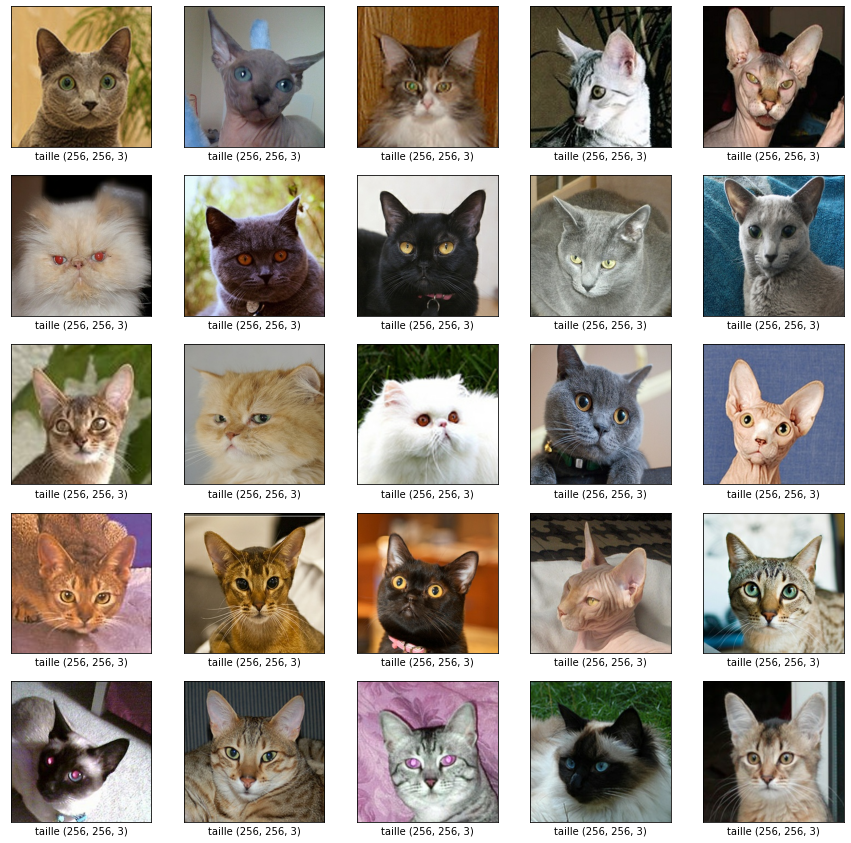

In [10]:
from os import listdir
from os.path import isfile, join


mypath='Data_Project/images/cat'
onlyfiles = [ f for f in listdir(mypath) if isfile(join(mypath,f)) ]
images = np.empty(len(onlyfiles), dtype=object)
for n in range(0, len(onlyfiles)):
  images[n] = cv2.imread( join(mypath,onlyfiles[n]) )


nb_columns = 25 # Nombre d'images à afficher

plt.figure(figsize=(15,15))
for i in range(nb_columns):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # cv2 lit met les images en BGR et matplotlib lit du RGB
    # il faut donc convertir pour afficher les bonnes couleurs
    images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    plt.imshow(images[i],cmap=plt.cm.binary)
    plt.xlabel('taille ' + str(images[i].shape))

In [20]:
IMG_SIZE=128

def create_training_data(path_data, list_classes):
  training_data=[]
  for classes in list_classes:
      path=os.path.join(path_data, classes)
      class_num=list_classes.index(classes)
      for img in os.listdir(path):
        try:
          img_array = cv2.imread(os.path.join(path,img), cv2.IMREAD_UNCHANGED)
          new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
          training_data.append([new_array, class_num])
        except Exception as e:
          pass
  return training_data

def create_X_y (path_data, list_classes):
      # récupération des données
      training_data=create_training_data(path_data, list_classes)
      # tri des données
      random.shuffle(training_data)
      # création de X et y
      X=[]
      y=[]
      for features, label in training_data:
        X.append(features)
        y.append(label)
      X=np.array(X).reshape(-1,IMG_SIZE, IMG_SIZE, 3)
      y=np.array(y)
      return X,y

Nombre de données :  800
Taille d'une image pour connaître l'input du réseau (128, 128, 3)
Distribution des labels dans le jeu d'apprentissage
Nombre d'éléments par classe 0    400
1    400
Name: count, dtype: int64


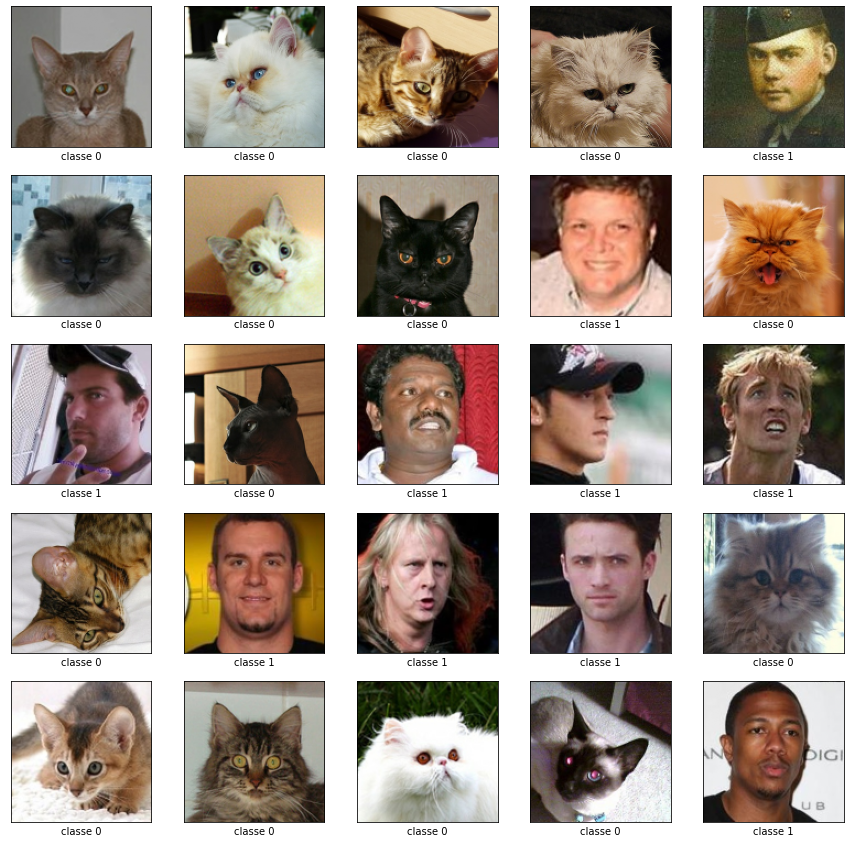

In [21]:
my_path="Data_Project/images/"
my_classes=['cat','man']
X,y=create_X_y (my_path,my_classes)


# Affichage d'exemples
plot_examples(X,y)

# Quelques informations sur les données
print ("Nombre de données : ",X.shape[0])
print ("Taille d'une image pour connaître l'input du réseau", X[0].shape)
print ("Distribution des labels dans le jeu d'apprentissage")
print("Nombre d'éléments par classe", pd.Series(y).value_counts())

In [23]:
#Normalisation: 
X=X.astype('float')
X=X/255.0

In [46]:
# Complétez la cellule
image_size=128

###
###inputs = Input(shape=(2,))
#1ere couche 
##x = Dense(32, activation="relu",name="1erecouche")(inputs)
#2eme couche 
##x= Dense(32, activation="relu",name="2emecouche")(x)
#relu = hidden_layer(layers intermediaires) , output non linéaire , peut être n'imp quelle valeur
#sigmoid = output_layer , classification binaire, probabilité 

##outputs = Dense(1, activation="sigmoid",name="output_layer")(x)

###
# 1 - Convolutional Layer
inputs = Input(shape=(128, 128, 3))


conv= Conv2D(4, (3, 3), activation='relu') (inputs)
    # 2 - Max-Pooling Layer
maxpool = MaxPooling2D(pool_size=(2, 2)) (conv)
    # 3 - Flatten Layer
flatten = Flatten() (maxpool)
    # 5 - Output Layer
output= Dense(1, activation='sigmoid') (flatten)

model = Model(inputs=inputs, outputs=output, name="cnn_minimal")

In [47]:
model.compile(optimizer=Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "cnn_minimal"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 4)    │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 15876)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │        15,877 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,989 (62.46 KB)

 Trainable params: 15,989 (62.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6582 - loss: 0.6142 - val_accuracy: 0.8750 - val_loss: 0.4804
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8125 - loss: 0.4877 - val_accuracy: 0.8984 - val_loss: 0.3780
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8984 - loss: 0.3684 - val_accuracy: 0.9453 - val_loss: 0.2834
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9375 - loss: 0.2276 - val_accuracy: 0.8828 - val_loss: 0.3042
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9395 - loss: 0.1737 - val_accuracy: 0.9375 - val_loss: 0.2284
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9551 - loss: 0.1345 - val_accuracy: 0.9219 - val_loss: 0.2427
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9590 - loss: 0.1174 - val_accuracy: 0.9141 - val_loss: 0.2349
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9609 - loss: 0.1050 - val_accuracy: 0.

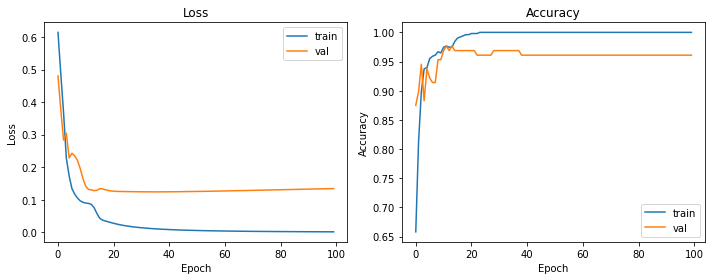

Test accuracy: 0.95


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
# Entraînement
epochs = 100
batch_size = 32
history = model.fit(
    X_train,y_train,epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1


)

# Courbes loss/accuracy
plot_history_simple(history)

# Évaluation sur X_test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", round(test_acc, 3))


              precision    recall  f1-score   support

     class 0      0.909     1.000     0.952        80
     class 1      1.000     0.900     0.947        80

    accuracy                          0.950       160
   macro avg      0.955     0.950     0.950       160
weighted avg      0.955     0.950     0.950       160



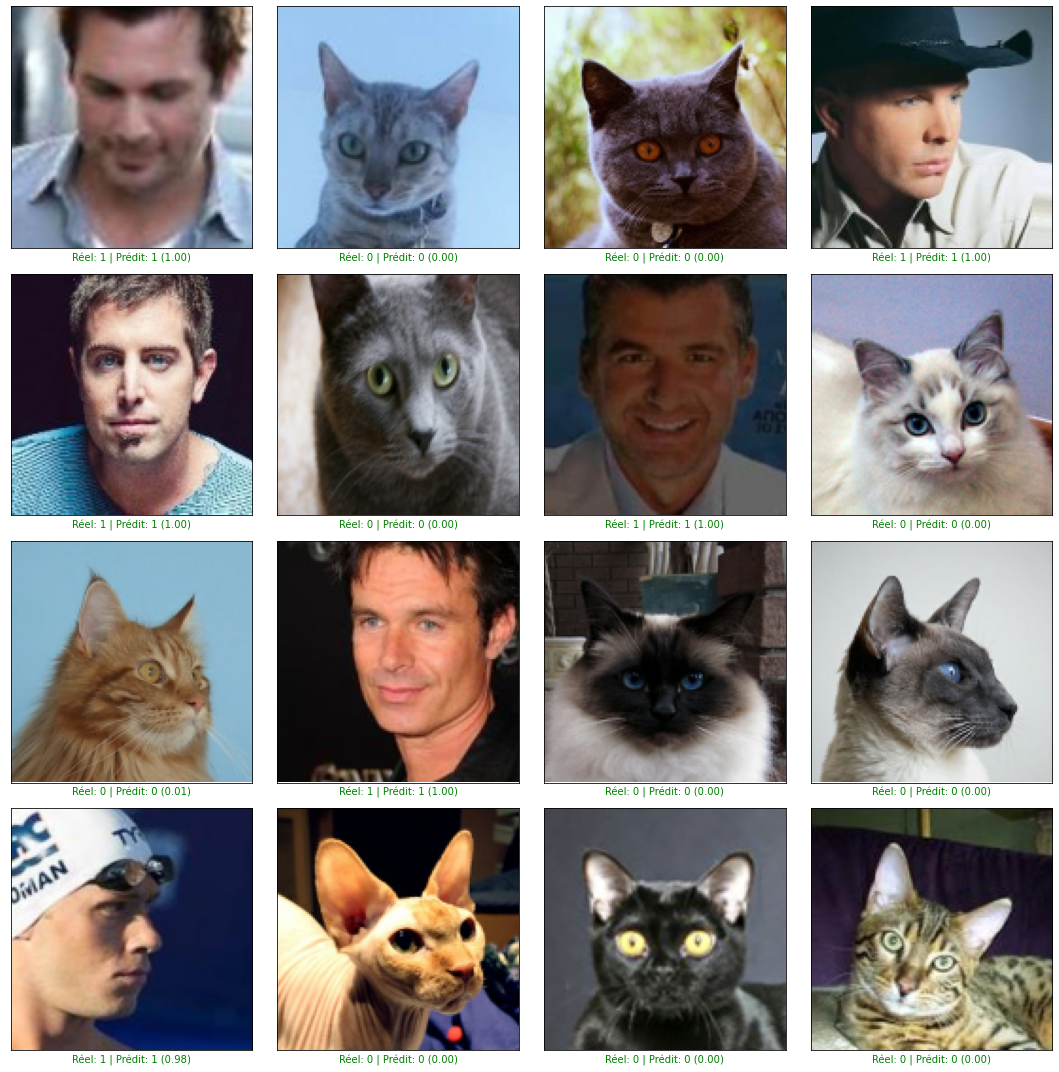

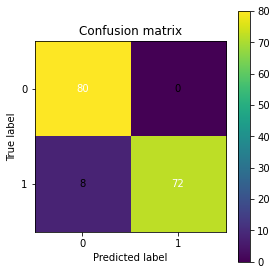

In [51]:
# Conversion de la probabilité en binaire
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred,
                            target_names=["class 0", "class 1"],
                            digits=3))
plot_predictions(model,X_test, y_test)
plot_confusion_matrix_simple(y_test, y_pred, labels=(0,1), normalize=None)

In [ ]:
# ImageDataGenerator 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
train_generator = train_datagen.flow_from_directory(
    'Data_Project/images/',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)
